In [1]:
from calendar import monthrange
from datetime import datetime

import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
from pytdigest import TDigest

from test_get_collections_and_files import list_files_and_excluded_vars
from test_make_digest import get_quantiles_from_tdigest  # returns (quantiles, quantile_list)


# First from the TUI, choose one data chunk you want to test

# inputs you choose
model = "geosfp"          # e.g. "geosfp"
year = 2024 
month = 2
day = 1
#id_string = "inst1_2d_hwl_Nx|CO2CL|None|Strat1"
#id_string =  "inst3_3d_aer_Nv|BCPHILIC|11.0|Strat2"#"inst3_3d_aer_Nv|MSA|10.0|Strat3"
id_string = "inst3_3d_aer_Nv|MSA|5.0|Strat2"
#"inst3_3d_chm_Nv|CO2|1.0|Strat2" #"inst3_3d_aer_Nv|SS001|13.0|Strat8"
#"inst3_3d_chm_Nv|CO2|1.0|Strat2"
#"tavg3_3d_cld_Np|RH|1.0|Strat7" #"inst3_3d_chm_Nv|CO|26.0|Strat4"
db_path = f"/home/sadhika8/JupyterLinks/nobackup/quads_database/{model}_monthly_aggregated_centroids_and_quantiles.db"

In [2]:
import os
import pyproj

proj_dir = pyproj.datadir.get_data_dir()
print("Using PROJ data dir:", proj_dir)

os.environ["PROJ_LIB"] = proj_dir
os.environ["PROJ_DATA"] = proj_dir

Using PROJ data dir: /usr/local/other/jupyter/lab/4.2.5/share/proj


In [3]:
# The following dictionary gives lat range for each stratum

Strata_dict = {
    "Strat1": {
        "lat": {"min": -90, "max": -70},
    },
    "Strat2": {
        "lat": {"min": -70, "max": -45},
    },
    "Strat3": {
        "lat": {"min": -45, "max": -20},
    },
    "Strat4": {
        "lat": {"min": -20, "max": 0},
    },
    "Strat5": {
        "lat": {"min": 0, "max": 20},
    },
    "Strat6": {
        "lat": {"min": 20, "max": 45},
    },
    "Strat7": {
        "lat": {"min": 45, "max": 70},
    },
    "Strat8": {
        "lat": {"min": 70, "max": 90},
    },
}

# parse the id_string displayed on the TUI

def parse_id_string(id_string: str, strata_dict: dict) -> dict:
    parts = id_string.split("|")
    if len(parts) != 4:
        raise ValueError(
            f"id_string must have 4 fields separated by '|', got: {id_string}"
        )

    collection, var, level_str, stratum = parts

    try:
        level = float(level_str)
    except: #ValueError as e:
        #raise ValueError(f"Could not parse level from '{level_str}'") from e
        level = "None"
    if stratum not in strata_dict:
        raise KeyError(f"Stratum '{stratum}' not found in Strata_dict")

    lat_info = strata_dict[stratum].get("lat")
    if lat_info is None:
        raise KeyError(f"No 'lat' entry found for stratum '{stratum}'")

    lat_min = lat_info["min"]
    lat_max = lat_info["max"]

    return {
        "collection": collection,
        "var": var,
        "level": level,
        "stratum": stratum,
        "lat_min": lat_min,
        "lat_max": lat_max,
    }


In [4]:
# now parse the id_string

parsed = parse_id_string(id_string, Strata_dict)

collection = parsed["collection"]
var = parsed["var"]
level = parsed["level"]
stratum = parsed["stratum"]
lat_min = parsed["lat_min"]
lat_max = parsed["lat_max"]

print("Extracted values:")
print(f"collection = {collection}")
print(f"var        = {var}")
print(f"level      = {level}")
print(f"stratum    = {stratum}")
print(f"lat_min    = {lat_min}")
print(f"lat_max    = {lat_max}")

Extracted values:
collection = inst3_3d_aer_Nv
var        = MSA
level      = 5.0
stratum    = Strat2
lat_min    = -70
lat_max    = -45


In [5]:
# load a t-digest for a given model/year/month/id_string from a database

def load_tdigest_from_db(db_path: Path, model: str, year: int, month: int, id_string: str):
    """
    Fetch (compression, centroids, quantiles, quantile_list) for a given key/month from SQLite.
    Returns None if not found.
    """
    table_name = model.lower()
    with sqlite3.connect(str(db_path)) as conn:
        row = conn.execute(
            f"SELECT compression, centroids, quantiles, quantile_list FROM {table_name} "
            "WHERE model=? AND year=? AND month=? AND id_string=?",
            (model, year, month, id_string),
        ).fetchone()
    #print(row)

    if row is None:
        print(
            f"No reference quantiles in DB for "
            f"(model={model}, year={year}, month={month}, id_string='{id_string}') "
            f"at {db_path}"
        )
        return None

    compression, centroids, quantiles, qlist =  row[0], pickle.loads(row[1]), pickle.loads(row[2]), pickle.loads(row[3])
    return {
            "year": year,
            "month": month,
            "compression": compression,
            "centroids": centroids,
            "quantiles": quantiles,
            "quantile_list": qlist,
            }

In [6]:
# merge digests to get the combined t-digest for last year, across three months time period

def combine_tdigest_refs(refs: list[dict]):
    """
    combine multiple DB-loaded tdigest references.
    """
    if not refs:
        return None

    compression = refs[0]["compression"]

    td_merged = None

    for ref in refs:
        centroids = ref["centroids"]
        #compression = ref["compression"]
        td = TDigest.of_centroids(np.asarray(centroids), compression=compression)

        td_merged = td if td_merged is None else TDigest.combine(td_merged, td)

    return td_merged

In [7]:
# for a given set of db_path: Path, model: str, year: int, month: int, id_string: str, write a function
# that does the following
# connect to the database
# load one year ago's digests (3, across three monhts)
# merge the 3 t-digests
# then find quantiles and q values and store them as x and y, which I will plot in the next cell
# this plot is what the tui also shows

from datetime import date
from dateutil.relativedelta import relativedelta
import sqlite3
import pickle
import numpy as np

def load_three_month_merged_quantiles(
    db_path,
    model: str,
    year: int,
    month: int,
    id_string: str,
):
    """
    Load t-digests from previous year's month-1, month, month+1,
    merge them, and return x=qlist and y=quantiles.
    """
   
    dates = []
    
    for i in range(1, 4):
        center_date = date(year-i, month, 1)
        
        dates += [
        center_date + relativedelta(months=-1),
        center_date,
        center_date + relativedelta(months=+1)]

    refs = []

    for dt in dates:
        with sqlite3.connect(db_path) as conn:
            conn.row_factory = sqlite3.Row
            cur = conn.cursor()

            cur.execute(
                f"""
                SELECT *
                FROM {model}
                WHERE year = ?
                  AND month = ?
                  AND id_string = ?
                LIMIT 1
                """,
                (dt.year, dt.month, id_string),
            )

            row = cur.fetchone()

        if row is None:
            print(f"No match found for year={dt.year}, month={dt.month}, id_string={id_string}")
            continue

        d = dict(row)

        for key in ["centroids", "quantiles", "quantile_list"]:
            if isinstance(d[key], (bytes, bytearray)):
                d[key] = pickle.loads(d[key])

        refs.append(d)

    if not refs:
        print("No matching rows found.")
        return None, None

    td_ref = combine_tdigest_refs(refs)

    ref_quantiles = get_quantiles_from_tdigest(td_ref)
    quantiles, qlist = ref_quantiles

    x = qlist
    y = quantiles

    return x, y

In [8]:
x, y = load_three_month_merged_quantiles(
    db_path=db_path,
    model=model,
    year=year,
    month=month,
    id_string=id_string,
)

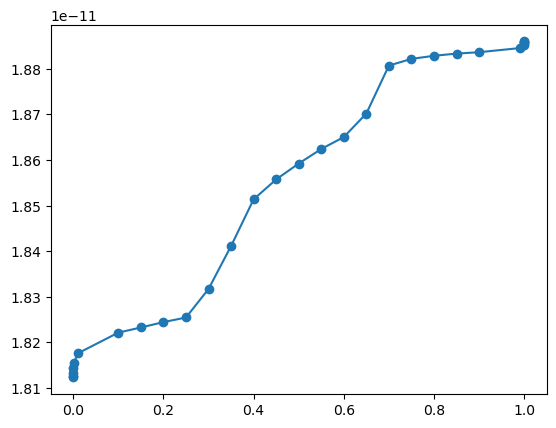

In [9]:
plt.scatter(x, y)
plt.plot(x, y)

In [10]:
from test_sanity_check_v2 import fence
fence_low, fence_high = fence((y, x))
print(fence_low, fence_high)
#fence_high = 8.60375785513416e-14
# fence_low and fence_high outputted here must match exactly to the values shown by the TUI
# if the value match exactly it indicates that the stored t-digests (in quads results)
# are correct and the 
# TUI is properly reading and plotting relevant 
# files/data from the quads results. If not exact match, something is wrong.

1.8014764321138967e-11 1.8910718276840526e-11


In [11]:
# Now, access the daily consolidated raw data for that chunk and verify that the number
# of data points above and below the computed fence. 
# This number should also match exactly what the TUI shows. Indicating the correctness of 
# the stored results and the TUI display - everything after the main backend code

# histogram and summary stats are optional - everything eles after the main backend database

def daily_histogram_for_collection(
    model,
    date,
    collection,
    var,
    data_yaml_file,
    lat_name="lat",
    lev_name="lev",
    lat_min=None,
    lat_max=None,
    level=None,
    bins=100,
    fence_low=None,
    fence_high=None,
):
    all_files = []
    excluded = []

    _, collection_map, excluded_vars = list_files_and_excluded_vars(
        model=model,
        date=date,
        data_yaml_file=data_yaml_file,
    )

    all_files.extend(collection_map.get(collection, []))

    if not excluded:
        excluded = excluded_vars

    print(f"Found {len(all_files)} files for collection {collection} on {date:%Y-%m-%d}")

    if not all_files:
        raise RuntimeError(
            f"No files found for collection={collection} on date={date:%Y-%m-%d}"
        )
    if model in ["MERRA2"]:
            day = date.day
            tag = f"{day:02d}.nc4" # note the assumption here
            all_files = [fi for fi in all_files if fi.endswith(tag)]
            print(day, all_files)

    ds = xr.open_mfdataset(
        all_files,
        combine="by_coords",
        drop_variables=excluded,
        data_vars="minimal",
        coords="minimal",
        compat="no_conflicts",
        engine="h5netcdf",
        chunks="auto",
        parallel=True,
    )

    da_var = ds[var]

    lat_vals = da_var[lat_name].values
    if lat_vals[0] <= lat_vals[-1]:
        da_var = da_var.sel({lat_name: slice(lat_min, lat_max)})
    else:
        da_var = da_var.sel({lat_name: slice(lat_max, lat_min)})

    if level is not None and lev_name in da_var.dims:
        da_var = da_var.sel({lev_name: level})

    arr = da_var.data
    arr = da.where(da.isfinite(arr), arr, np.nan)

    n = da.sum(~da.isnan(arr)).compute()
    mean_val = da.nanmean(arr).compute()
    std_val = da.nanstd(arr).compute()
    min_val = da.nanmin(arr).compute()
    max_val = da.nanmax(arr).compute()

    print("N:", int(n))
    print("mean:", float(mean_val))
    print("std:", float(std_val))
    print("min:", float(min_val))
    print("max:", float(max_val))

    flat = arr.ravel()
    finite_vals = flat[da.isfinite(flat)]

    if fence_low is not None and fence_high is not None:
        left_violations = (finite_vals < fence_low).sum().compute()
        right_violations = (finite_vals > fence_high).sum().compute()
        print("left_violations:", int(left_violations))
        print("right_violations:", int(right_violations))
        print(left_violations + right_violations)

    hist, bin_edges = da.histogram(
        finite_vals,
        bins=bins,
        range=(float(min_val), float(max_val)),
    )
    hist = hist.compute()

    plt.figure()
    plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align="edge")
    plt.title(f"Histogram: {var} ({date:%Y-%m-%d})")
    plt.xlabel(var)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D01
Found 8 files for collection inst3_3d_aer_Nv on 2024-02-01
N: 930816
mean: 1.7733970542055388e-11
std: 2.998613523826944e-14
min: 1.745629855942621e-11
max: 1.7773666219356166e-11
left_violations: 930816
right_violations: 0
930816


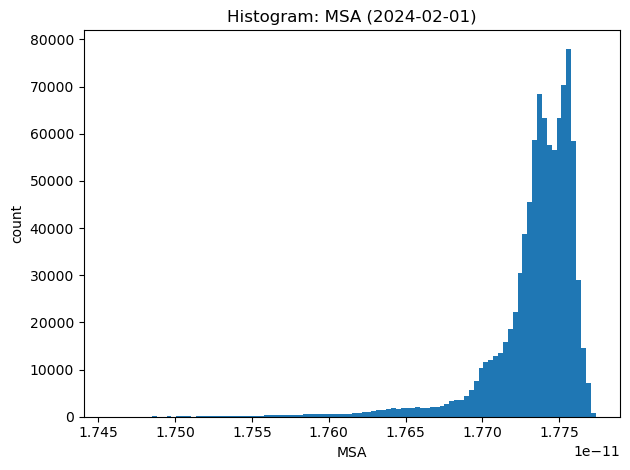

In [12]:
from datetime import datetime

daily_histogram_for_collection(
    model=model.upper(),
    date=datetime(year, month, day),
    collection= collection, #"inst3_3d_aer_Nv", #"inst1_2d_hwl_Nx","inst3_3d_aer_Nv|BCPHILIC|8.0|Strat2"
    var= var, #"BCPHILIC", #"CO2CL",
    data_yaml_file="/home/sadhika8/JupyterLinks/nobackup/quads_dev/conf/dataserver.yaml",
    lat_name="lat",
    lat_min= lat_min, #-90,
    lat_max= lat_max, #-70,
    level= level, # None
    bins=100,
    fence_low=fence_low,
    fence_high=fence_high,
)

In [133]:
# now analyze the monthly reference data itself - starting from the raw data
# compute histogram
# compute t-digest and fence
# the tui (the current version) does not display the monthly reference t-digests
# however, the monthly reference t-digests are computed by the backend code and are stored in 
# the SQLite database
# the older version of the TUI can visualize them too. Use that TUI to validate the 
# correctness of the backend code

In [13]:
from calendar import monthrange

def monthly_data_for_collection(
    model,
    year,
    month,
    collection,
    var,
    data_yaml_file,
    lat_name="lat",
    lev_name="lev",
    lat_min=None,
    lat_max=None,
    level=None,
):
    all_files = []
    excluded = []

    for day in range(1, monthrange(year, month)[1] + 1):
        _, collection_map, excluded_vars = list_files_and_excluded_vars(
            model=model,
            date=datetime(year, month, day),
            data_yaml_file=data_yaml_file,
        )

        all_files.extend(collection_map.get(collection, []))

        if not excluded:
            excluded = excluded_vars

    print(f"Found {len(all_files)} files for collection {collection}")

    if not all_files:
        raise FileNotFoundError(
            f"No files found for model={model}, year={year}, month={month}, collection={collection}"
        )
    all_files = list(set(all_files))
    print(len(all_files))

    ds = xr.open_mfdataset(
        all_files,
        combine="by_coords",
        drop_variables=excluded,
        data_vars="minimal",
        coords="minimal",
        compat="no_conflicts",
        engine="h5netcdf",
        chunks="auto",
        parallel=True,
    )

    da_var = ds[var]

    lat_coord = da_var[lat_name]
    if lat_coord[0] <= lat_coord[-1]:
        da_var = da_var.sel({lat_name: slice(lat_min, lat_max)})
    else:
        da_var = da_var.sel({lat_name: slice(lat_max, lat_min)})

    if level is not None and lev_name in da_var.dims:
        da_var = da_var.sel({lev_name: level})

    arr = da_var.data
    arr = da.where(da.isfinite(arr), arr, np.nan)

    return arr

In [14]:
arr = monthly_data_for_collection(
    model=model.upper(),
    year=year-1,
    month=month, #
    collection=collection,#"inst3_3d_aer_Nv", #"inst1_2d_hwl_Nx", BCPHILIC
    var=var,#"BCPHILIC", #"CO2CL",
    data_yaml_file="/home/sadhika8/JupyterLinks/nobackup/quads_dev/conf/dataserver.yaml",
    lat_name="lat",
    lev_name="lev",
    lat_min=lat_min,
    lat_max=lat_max,
    level=level,
)

GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D01
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D02
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D03
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D04
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D05
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D06
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D07
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D08
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D09
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D10


In [15]:
arr_np = arr.compute()
finite_vals = arr_np[np.isfinite(arr_np)]

n = finite_vals.size
mean = np.mean(finite_vals)
std = np.std(finite_vals)
min_val = np.min(finite_vals)
max_val = np.max(finite_vals)

print(f"N: {n}")
print(f"mean: {mean}")
print(f"std: {std}")
print(f"min: {min_val}")
print(f"max: {max_val}")

N: 26062848
mean: 1.8235957882639653e-11
std: 9.77718696070851e-15
min: 1.8175867061431816e-11
max: 1.8256266290372913e-11


In [16]:
print(var)

MSA


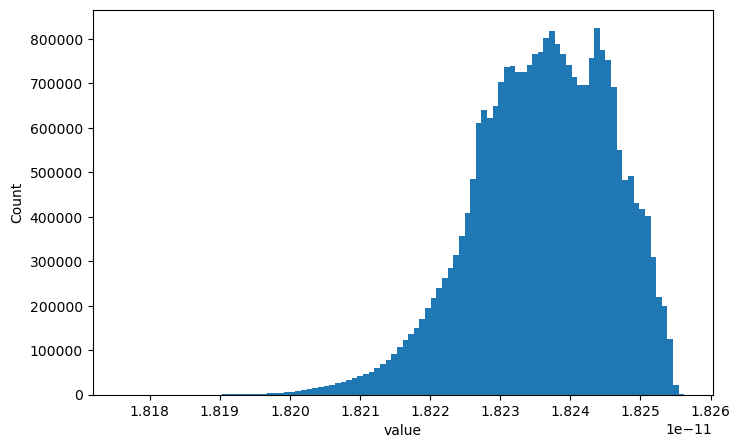

In [17]:
hist, bin_edges = np.histogram(finite_vals, bins=100)

plt.figure(figsize=(8, 5))
plt.bar(
    bin_edges[:-1],
    hist,
    width=np.diff(bin_edges),
    align="edge",
)
plt.xlabel("value")
plt.ylabel("Count")
#plt.yscale("log")
#plt.title(f"Histogram of")
plt.show()

In [18]:
#from pytdigest import TDigest
#from test_make_digest import get_quantiles_from_tdigest

td = TDigest.compute(finite_vals, compression=300)

In [19]:
quantiles, quantile_list = get_quantiles_from_tdigest(td)

In [20]:
#print(quantiles)

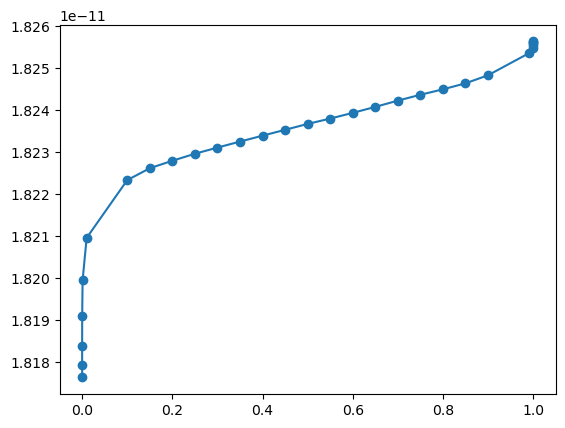

In [21]:
plt.plot(quantile_list, quantiles)
plt.scatter(quantile_list, quantiles)

In [22]:
fence_low, fence_high = fence((quantiles, quantile_list))
print(fence_low, fence_high)

# the below numbers has to match exactly with what the old tui displays

1.814455842219669e-11 1.8260859647049996e-11


In [23]:
#for i, j in zip(quantile_list, quantiles):
#        print([i, j])

In [24]:
#print(quantiles)

In [25]:
# Now, look at nine months of raw data, compute the monthly digeststs, merge them
# and print. This has to match exactly with what the TUI shows. If it does it means that the 
# main backend code for t-digest compuation, 3months merging for results, and display by the tui,
# all matches with the calculation of t-digest and fence using the raw data. Indicating that the
# entire quads codebase starting from the main backend to the TUI is correct.
# One caveat though: the exact match is only expected for MERRA2 only
# for other models the values may slightly differ because in the original code
# daily digests are computed first and then merged to find monthly digests
# but here I aggregate the monthly data first and then compute the digest once

# also plot a histogram for inspection

from datetime import date
from dateutil.relativedelta import relativedelta
import numpy as np

def merged_raw_digest():
    
    dates = []
    
    for i in range(1, 4):
        center_date = date(year-i, month, 1)
        
        dates += [
        center_date + relativedelta(months=-1),
        center_date,
        center_date + relativedelta(months=+1)]

    tds = []

    for dt in dates:
        arr = monthly_data_for_collection(
            model=model.upper(),
            year=dt.year,
            month=dt.month,
            collection=collection,
            var=var,
            data_yaml_file="/home/sadhika8/JupyterLinks/nobackup/quads_dev/conf/dataserver.yaml",
            lat_name="lat",
            lev_name="lev",
            lat_min=lat_min,
            lat_max=lat_max,
            level=level,
        )

        arr_np = arr.compute()
        finite_vals = arr_np[np.isfinite(arr_np)]

        td = TDigest.compute(finite_vals, compression=300)
        tds.append(td)
        print(f"done for {dt}")
    td_ref = tds[0]
    for td in tds[1:]:
        td_ref = TDigest.combine(td_ref, td)

    quantiles, quantile_list = get_quantiles_from_tdigest(td_ref)

    return quantiles, quantile_list, finite_vals

#quantiles, quantile_list = merged_raw_digest()
#fence_low, fence_high = fence((quantiles, quantile_list))
#print(fence_low, fence_high)
    

In [ ]:
quantiles, quantile_list, data = merged_raw_digest()
fence_low, fence_high = fence((quantiles, quantile_list))
#print(fence_low, fence_high)
    

GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M01/D01
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M01/D02
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M01/D03
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M01/D04
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M01/D05
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M01/D06
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M01/D07
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M01/D08
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M01/D09
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M01/D10


In [ ]:
print(fence_low, fence_high)
#print(data)

In [ ]:
mean_val = np.mean(data)
min_val = np.min(data)
max_val = np.max(data)

# Print statistics
print(f"Mean: {mean_val:.2f}")
print(f"Min: {min_val}")
print(f"Max: {max_val}")

hist, bin_edges = np.histogram(data, bins=100)

plt.figure(figsize=(8, 5))
plt.bar(
    bin_edges[:-1],
    hist,
    width=np.diff(bin_edges),
    align="edge",
)
plt.xlabel("value")
plt.ylabel("Count")
#plt.yscale("log")
#plt.title(f"Histogram of")
plt.show()

In [ ]:
# everything looks consistent here. One thing that is still annoying here is that 
# the number of violations my quads predicts is much more than what Tariq's quads predicted
# I suspect that the raw data we are using are from different sources. True for GEOSIT and M
# MERRA2

# Note that in the above test, I do not enforce physical test --
# I have seen Tariq's quads having higher upper bound for t-digest fence compared with
# mine. I need to figure out why my fence would be lower

# found equal number of data points between mine and Tariq's data chunks -- reassuring
# 
# tune with fence parameters to see if I can see the same value 192 total Violations as
# Tariqs'. This will be a good test!